# Steam 인디게임 흥행지표

| 축 | 의미 | 주요 지표 |
|---|---|---|
| 반응의 규모 | 얼마나 많은 유저 반응을 만들었는가 | D7/D30/D90 리뷰 수, D30 리뷰 속도 |
| 반응의 품질 | 그 반응이 좋은 평가였는가 | D30 긍정률, Wilson Score |
| 반응의 유지력 | 초반 이후에도 관심이 이어졌는가 | D31~D90 리뷰 수, D30 이후 리뷰 유지 비율 |

보고자 하는것

1. 리뷰 수는 반응의 규모를 보여준다.
2. 긍정률은 반응의 품질을 보여준다.
3. Wilson Score는 긍정률의 신뢰도를 보정한다.
4. D30 이후 리뷰 증가량은 반응의 유지력을 보여준다.
5. 따라서 흥행지표는 단일 지표가 아니라 3축 구조로 봐야 한다.

In [35]:
import pandas as pd
import numpy as np
import ast

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams[
        'font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

In [36]:
# 파일 경로
# 프로젝트 루트 직접 지정
ROOT = Path(r"C:\Users\joon5\Documents\github\steam-indie-game-analysis")

# data/processed 폴더
DATA_DIR = ROOT / "data" / "processed"

# 파일 경로
LIST_PATH = DATA_DIR / "steam_indie_list_202604211615.csv"
REVIEW_PATH = DATA_DIR / "steam_indie_reviews_202604230927.csv"
HIST_PATH = DATA_DIR / "review_histogram_v4.csv"

# 데이터 불러오기
game_df = pd.read_csv(LIST_PATH)
review_df = pd.read_csv(REVIEW_PATH)
hist_df = pd.read_csv(HIST_PATH)

print("game_df:", game_df.shape)
print("review_df:", review_df.shape)
print("hist_df:", hist_df.shape)

game_df: (61266, 12)
review_df: (13106, 21)
hist_df: (6003, 9)


In [37]:
display(game_df.head())
display(review_df.head())
display(hist_df.head())

,appid,spy_name,owners,positive,negative,price_spy,ccu,name_store,type,genres,release_date,developers
0,1623730,Palworld,"50,000,000 .. 100,000,000",358266,22443,2999,18028,Palworld,game,"['Action', 'Adventure', 'Indie', 'RPG', 'Early...","18 Jan, 2024",Pocketpair
1,304930,Unturned,"50,000,000 .. 100,000,000",506516,48852,0,10408,Unturned,game,"['Action', 'Adventure', 'Casual', 'Indie', 'Fr...","7 Jul, 2017",Smartly Dressed Games
2,105600,Terraria,"20,000,000 .. 50,000,000",1373979,35494,999,24580,Terraria,game,"['Action', 'Adventure', 'Indie', 'RPG']","16 May, 2011",Re-Logic
3,431960,Wallpaper Engine,"20,000,000 .. 50,000,000",876898,17560,499,91184,Wallpaper Engine,game,"['Casual', 'Indie', 'Animation & Modeling', 'D...","16 Nov, 2018",Wallpaper Engine Team
4,291550,Brawlhalla,"20,000,000 .. 50,000,000",314809,71647,0,14169,Brawlhalla,game,"['Action', 'Indie', 'Free To Play']","17 Oct, 2017",Blue Mammoth Games


,recommendationid,appid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,...,steam_purchase,received_for_free,written_during_early_access,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played
0,134554560,1432860,english,"For me, Sun Haven is a fun farming game that h...",1678643330,1678643330,True,1432,25,0.971922,...,True,False,False,76561199471119493,0,1,4120,0,1723,1763967370
1,135610350,1432860,english,*Updated for v1.0.3*\n\nI really love this gam...,1680018629,1680192211,False,1564,18,0.939696,...,True,False,False,76561198107464933,663,108,12951,0,8605,1690050219
2,136483272,1432860,english,(Singleplayer review)\nPuh i am not really sur...,1681149417,1681149417,True,166,0,0.917131,...,True,False,False,76561198005466151,1021,4,3653,0,3400,1723728962
3,138973732,1432860,russian,"Я наиграла в эту игру почти 55 часов, 40+ из к...",1685034459,1685034459,False,224,7,0.897391,...,True,False,False,76561198098873026,720,16,3280,0,3280,1684534023
4,136801481,1432860,japanese,Sun Haven好きさんが増えると嬉しいので、初めてレビューします。\n\nこれを見たあな...,1681649431,1682154116,True,143,10,0.895801,...,True,False,False,76561199151368353,0,1,12057,0,7849,1723475976


,appid,name,stratum,release_date,date,recommendations_up,recommendations_down,rollup_type,data_type
0,1432860,Sun Haven,large_high,2023-03-10,1622505600,280,34,month,rollups
1,1432860,Sun Haven,large_high,2023-03-10,1625097600,448,46,month,rollups
2,1432860,Sun Haven,large_high,2023-03-10,1627776000,170,27,month,rollups
3,1432860,Sun Haven,large_high,2023-03-10,1630454400,112,18,month,rollups
4,1432860,Sun Haven,large_high,2023-03-10,1633046400,116,10,month,rollups


In [38]:
print("[game_df 컬럼]")
print(game_df.columns.tolist())

print("\n[review_df 컬럼]")
print(review_df.columns.tolist())

print("\n[hist_df 컬럼]")
print(hist_df.columns.tolist())

[game_df 컬럼]
['appid', 'spy_name', 'owners', 'positive', 'negative', 'price_spy', 'ccu', 'name_store', 'type', 'genres', 'release_date', 'developers']

[review_df 컬럼]
['recommendationid', 'appid', 'language', 'review', 'timestamp_created', 'timestamp_updated', 'voted_up', 'votes_up', 'votes_funny', 'weighted_vote_score', 'comment_count', 'steam_purchase', 'received_for_free', 'written_during_early_access', 'author_steamid', 'author_num_games_owned', 'author_num_reviews', 'author_playtime_forever', 'author_playtime_last_two_weeks', 'author_playtime_at_review', 'author_last_played']

[hist_df 컬럼]
['appid', 'name', 'stratum', 'release_date', 'date', 'recommendations_up', 'recommendations_down', 'rollup_type', 'data_type']


In [39]:
# game_df에서 사용할 컬럼
game_cols = [
    "appid", "spy_name", "owners", "positive", "negative",
    "price_spy", "ccu", "genres", "release_date"
]

# review_df에서 사용할 컬럼
review_cols = [
    "recommendationid", "appid", "language", "timestamp_created",
    "voted_up", "steam_purchase", "received_for_free",
    "written_during_early_access", "author_playtime_at_review"
]

display(game_df[game_cols].head())
display(review_df[review_cols].head())

,appid,spy_name,owners,positive,negative,price_spy,ccu,genres,release_date
0,1623730,Palworld,"50,000,000 .. 100,000,000",358266,22443,2999,18028,"['Action', 'Adventure', 'Indie', 'RPG', 'Early...","18 Jan, 2024"
1,304930,Unturned,"50,000,000 .. 100,000,000",506516,48852,0,10408,"['Action', 'Adventure', 'Casual', 'Indie', 'Fr...","7 Jul, 2017"
2,105600,Terraria,"20,000,000 .. 50,000,000",1373979,35494,999,24580,"['Action', 'Adventure', 'Indie', 'RPG']","16 May, 2011"
3,431960,Wallpaper Engine,"20,000,000 .. 50,000,000",876898,17560,499,91184,"['Casual', 'Indie', 'Animation & Modeling', 'D...","16 Nov, 2018"
4,291550,Brawlhalla,"20,000,000 .. 50,000,000",314809,71647,0,14169,"['Action', 'Indie', 'Free To Play']","17 Oct, 2017"


,recommendationid,appid,language,timestamp_created,voted_up,steam_purchase,received_for_free,written_during_early_access,author_playtime_at_review
0,134554560,1432860,english,1678643330,True,True,False,False,1723
1,135610350,1432860,english,1680018629,False,True,False,False,8605
2,136483272,1432860,english,1681149417,True,True,False,False,3400
3,138973732,1432860,russian,1685034459,False,True,False,False,3280
4,136801481,1432860,japanese,1681649431,True,True,False,False,7849


# 기본 전처리

In [40]:
game_base = game_df.copy()

# 누적 전체 리뷰 수
game_base["total_reviews"] = game_base["positive"] + game_base["negative"]

# 누적 긍정률
game_base["positive_ratio"] = game_base["positive"] / game_base["total_reviews"]

# owners 문자열 분리
owner_split = game_base["owners"].str.split(" .. ", expand=True)

game_base["owners_min"] = (
    owner_split[0]
    .str.replace(",", "", regex=False)
    .astype(int)
)

game_base["owners_max"] = (
    owner_split[1]
    .str.replace(",", "", regex=False)
    .astype(int)
)

# owners 중간값
game_base["owners_mid"] = (
    game_base["owners_min"] + game_base["owners_max"]
) / 2

# 출시일 변환
game_base["release_dt"] = pd.to_datetime(
    game_base["release_date"],
    errors="coerce"
)

# genres 문자열을 리스트로 변환
game_base["genres_list"] = game_base["genres"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)

display(
    game_base[
        [
            "appid", "spy_name", "owners", "owners_mid",
            "positive", "negative", "total_reviews",
            "positive_ratio", "ccu", "genres_list", "release_dt"
        ]
    ].head()
)

,appid,spy_name,owners,owners_mid,positive,negative,total_reviews,positive_ratio,ccu,genres_list,release_dt
0,1623730,Palworld,"50,000,000 .. 100,000,000",75000000.0,358266,22443,380709,0.941049,18028,"[Action, Adventure, Indie, RPG, Early Access]",2024-01-18
1,304930,Unturned,"50,000,000 .. 100,000,000",75000000.0,506516,48852,555368,0.912037,10408,"[Action, Adventure, Casual, Indie, Free To Play]",2017-07-07
2,105600,Terraria,"20,000,000 .. 50,000,000",35000000.0,1373979,35494,1409473,0.974818,24580,"[Action, Adventure, Indie, RPG]",2011-05-16
3,431960,Wallpaper Engine,"20,000,000 .. 50,000,000",35000000.0,876898,17560,894458,0.980368,91184,"[Casual, Indie, Animation & Modeling, Design &...",2018-11-16
4,291550,Brawlhalla,"20,000,000 .. 50,000,000",35000000.0,314809,71647,386456,0.814605,14169,"[Action, Indie, Free To Play]",2017-10-17


In [41]:
review_base = review_df.copy()

# 리뷰 작성일 변환
review_base["review_dt"] = pd.to_datetime(
    review_base["timestamp_created"],
    unit="s",
    errors="coerce"
)

# 게임 출시일 붙이기
review_base = review_base.merge(
    game_base[["appid", "spy_name", "release_dt", "genres_list"]],
    on="appid",
    how="left"
)

# 출시일 기준 며칠 뒤 리뷰인지 계산
review_base["days_from_release"] = (
    review_base["review_dt"] - review_base["release_dt"]
).dt.days

display(
    review_base[
        [
            "appid", "spy_name", "review_dt", "release_dt",
            "days_from_release", "voted_up",
            "steam_purchase", "received_for_free"
        ]
    ].head()
)

,appid,spy_name,review_dt,release_dt,days_from_release,voted_up,steam_purchase,received_for_free
0,1432860,Sun Haven,2023-03-12 17:48:50,2023-03-10,2,True,True,False
1,1432860,Sun Haven,2023-03-28 15:50:29,2023-03-10,18,False,True,False
2,1432860,Sun Haven,2023-04-10 17:56:57,2023-03-10,31,True,True,False
3,1432860,Sun Haven,2023-05-25 17:07:39,2023-03-10,76,False,True,False
4,1432860,Sun Haven,2023-04-16 12:50:31,2023-03-10,37,True,True,False


## 분석에 쓸 리뷰만 필터링

- 출시일 이후 작성된 리뷰
- 출시 후 90일 이내 리뷰
- Steam 구매 리뷰

In [42]:
review_valid = review_base[
    (review_base["days_from_release"] >= 0) &
    (review_base["days_from_release"] <= 90) &
    (review_base["steam_purchase"] == True)
].copy()

print("전체 리뷰 수:", len(review_base))
print("분석 사용 리뷰 수:", len(review_valid))
print("분석 게임 수:", review_valid["appid"].nunique())

display(review_valid.head())

전체 리뷰 수: 13106
분석 사용 리뷰 수: 13084
분석 게임 수: 73


,recommendationid,appid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,...,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,review_dt,spy_name,release_dt,genres_list,days_from_release
0,134554560,1432860,english,"For me, Sun Haven is a fun farming game that h...",1678643330,1678643330,True,1432,25,0.971922,...,1,4120,0,1723,1763967370,2023-03-12 17:48:50,Sun Haven,2023-03-10,"[Adventure, Casual, Indie, RPG, Simulation]",2
1,135610350,1432860,english,*Updated for v1.0.3*\n\nI really love this gam...,1680018629,1680192211,False,1564,18,0.939696,...,108,12951,0,8605,1690050219,2023-03-28 15:50:29,Sun Haven,2023-03-10,"[Adventure, Casual, Indie, RPG, Simulation]",18
2,136483272,1432860,english,(Singleplayer review)\nPuh i am not really sur...,1681149417,1681149417,True,166,0,0.917131,...,4,3653,0,3400,1723728962,2023-04-10 17:56:57,Sun Haven,2023-03-10,"[Adventure, Casual, Indie, RPG, Simulation]",31
3,138973732,1432860,russian,"Я наиграла в эту игру почти 55 часов, 40+ из к...",1685034459,1685034459,False,224,7,0.897391,...,16,3280,0,3280,1684534023,2023-05-25 17:07:39,Sun Haven,2023-03-10,"[Adventure, Casual, Indie, RPG, Simulation]",76
4,136801481,1432860,japanese,Sun Haven好きさんが増えると嬉しいので、初めてレビューします。\n\nこれを見たあな...,1681649431,1682154116,True,143,10,0.895801,...,1,12057,0,7849,1723475976,2023-04-16 12:50:31,Sun Haven,2023-03-10,"[Adventure, Casual, Indie, RPG, Simulation]",37


# 주장1: 반응의 규모는 리뷰 수로 본다

## 게임별 D7 / D30 / D90 리뷰 수 만들기

In [43]:
# D7 리뷰
d7_reviews = review_valid[
    review_valid["days_from_release"] <= 7
].copy()

# D30 리뷰
d30_reviews = review_valid[
    review_valid["days_from_release"] <= 30
].copy()

# D90 리뷰
d90_reviews = review_valid[
    review_valid["days_from_release"] <= 90
].copy()

print("D7 리뷰 수:", len(d7_reviews))
print("D30 리뷰 수:", len(d30_reviews))
print("D90 리뷰 수:", len(d90_reviews))

D7 리뷰 수: 5604
D30 리뷰 수: 9192
D90 리뷰 수: 13084


## 게임별 기간 리뷰 수 집계

In [44]:
d7_summary = (
    d7_reviews
    .groupby(["appid", "spy_name"], as_index=False)
    .agg(
        d7_reviews=("recommendationid", "count"),
        d7_positive=("voted_up", "sum")
    )
)

d30_summary = (
    d30_reviews
    .groupby(["appid", "spy_name"], as_index=False)
    .agg(
        d30_reviews=("recommendationid", "count"),
        d30_positive=("voted_up", "sum")
    )
)

d90_summary = (
    d90_reviews
    .groupby(["appid", "spy_name"], as_index=False)
    .agg(
        d90_reviews=("recommendationid", "count"),
        d90_positive=("voted_up", "sum")
    )
)

display(d7_summary.head())
display(d30_summary.head())
display(d90_summary.head())

,appid,spy_name,d7_reviews,d7_positive
0,877200,Zero Caliber VR,18,14
1,1000440,东方雪莲华 ～ Abyss Soul Lotus.,146,132
2,1049590,Eternal Return,72,36
3,1106140,The Drift Challenge,4,2
4,1116540,DAVIGO: VR vs. PC,46,36


,appid,spy_name,d30_reviews,d30_positive
0,877200,Zero Caliber VR,44,30
1,1000440,东方雪莲华 ～ Abyss Soul Lotus.,182,164
2,1049590,Eternal Return,120,70
3,1106140,The Drift Challenge,6,2
4,1116540,DAVIGO: VR vs. PC,92,74


,appid,spy_name,d90_reviews,d90_positive
0,877200,Zero Caliber VR,132,98
1,1000440,东方雪莲华 ～ Abyss Soul Lotus.,200,182
2,1049590,Eternal Return,200,134
3,1106140,The Drift Challenge,12,6
4,1116540,DAVIGO: VR vs. PC,200,162


# 주장 2: 반응의 품질은 긍정률로 본다

In [45]:
# D30 부정 리뷰 수
d30_summary["d30_negative"] = (
    d30_summary["d30_reviews"] - d30_summary["d30_positive"]
)

# D30 긍정률
d30_summary["d30_positive_ratio"] = (
    d30_summary["d30_positive"] / d30_summary["d30_reviews"]
)

# D30 리뷰 속도
d30_summary["d30_review_velocity"] = (
    d30_summary["d30_reviews"] / 30
)

display(
    d30_summary[
        [
            "appid", "spy_name",
            "d30_reviews", "d30_positive",
            "d30_negative", "d30_positive_ratio",
            "d30_review_velocity"
        ]
    ].head()
)

,appid,spy_name,d30_reviews,d30_positive,d30_negative,d30_positive_ratio,d30_review_velocity
0,877200,Zero Caliber VR,44,30,14,0.681818,1.466667
1,1000440,东方雪莲华 ～ Abyss Soul Lotus.,182,164,18,0.901099,6.066667
2,1049590,Eternal Return,120,70,50,0.583333,4.000000
3,1106140,The Drift Challenge,6,2,4,0.333333,0.200000
4,1116540,DAVIGO: VR vs. PC,92,74,18,0.804348,3.066667


# Wilson Score 계산

In [46]:
def wilson_score(pos, total, z=1.96):
    """
    Wilson Score Lower Bound 계산 함수
    
    pos   : 긍정 리뷰 수
    total : 전체 리뷰 수
    z     : 1.96은 약 95% 신뢰수준
    """
    if total == 0:
        return np.nan
    
    p = pos / total
    
    numerator = (
        p
        + z**2 / (2 * total)
        - z * np.sqrt((p * (1 - p) + z**2 / (4 * total)) / total)
    )
    
    denominator = 1 + z**2 / total
    
    return numerator / denominator

In [47]:
d30_summary["d30_wilson_score"] = d30_summary.apply(
    lambda row: wilson_score(
        row["d30_positive"],
        row["d30_reviews"]
    ),
    axis=1
)

display(
    d30_summary[
        [
            "appid", "spy_name",
            "d30_reviews", "d30_positive_ratio",
            "d30_wilson_score"
        ]
    ].sort_values("d30_wilson_score", ascending=False).head(20)
)

,appid,spy_name,d30_reviews,d30_positive_ratio,d30_wilson_score
52,2527500,MiSide,168,1.000000,0.977645
22,1671210,DELTARUNE,164,1.000000,0.977112
32,2078510,VIVIDLOPE,162,1.000000,0.976836
67,3087650,A Shelter Full of Cats,140,0.985714,0.949411
11,1299690,Gori: Cuddly Carnage,120,0.983333,0.941263
30,2004590,Conbunn Cardboard,168,0.976190,0.940387
60,2746910,Three Kingdoms: The Blood Moon,132,0.969697,0.924674
6,1175360,Doomsday Hunters,154,0.961039,0.917612
40,2198150,Tiny Glade,150,0.960000,0.915485
9,1240060,A Highland Song,162,0.950617,0.905590


# 주장 3: 반응의 유지력은 D30 이후 리뷰 증가량으로 본다

In [48]:
post_d30_reviews = review_valid[
    (review_valid["days_from_release"] > 30) &
    (review_valid["days_from_release"] <= 90)
].copy()

post_d30_summary = (
    post_d30_reviews
    .groupby(["appid", "spy_name"], as_index=False)
    .agg(
        post_d30_reviews=("recommendationid", "count"),
        post_d30_positive=("voted_up", "sum")
    )
)

display(post_d30_summary.head())

,appid,spy_name,post_d30_reviews,post_d30_positive
0,877200,Zero Caliber VR,88,68
1,1000440,东方雪莲华 ～ Abyss Soul Lotus.,18,18
2,1049590,Eternal Return,80,64
3,1106140,The Drift Challenge,6,4
4,1116540,DAVIGO: VR vs. PC,108,88


In [49]:
success_df = d30_summary.copy()

# D7 붙이기
success_df = success_df.merge(
    d7_summary[["appid", "d7_reviews", "d7_positive"]],
    on="appid",
    how="left"
)

# D90 붙이기
success_df = success_df.merge(
    d90_summary[["appid", "d90_reviews", "d90_positive"]],
    on="appid",
    how="left"
)

# D30 이후 리뷰 붙이기
success_df = success_df.merge(
    post_d30_summary[["appid", "post_d30_reviews", "post_d30_positive"]],
    on="appid",
    how="left"
)

# 결측치 처리
fill_cols = [
    "d7_reviews", "d7_positive",
    "d90_reviews", "d90_positive",
    "post_d30_reviews", "post_d30_positive"
]

success_df[fill_cols] = success_df[fill_cols].fillna(0)

# D90 긍정률
success_df["d90_positive_ratio"] = (
    success_df["d90_positive"] / success_df["d90_reviews"]
)

# 반응 유지 비율
success_df["review_retention_ratio"] = (
    success_df["post_d30_reviews"] / success_df["d30_reviews"]
)

display(success_df.head())

,appid,spy_name,d30_reviews,d30_positive,d30_negative,d30_positive_ratio,d30_review_velocity,d30_wilson_score,d7_reviews,d7_positive,d90_reviews,d90_positive,post_d30_reviews,post_d30_positive,d90_positive_ratio,review_retention_ratio
0,877200,Zero Caliber VR,44,30,14,0.681818,1.466667,0.534428,18.0,14.0,132,98,88.0,68.0,0.742424,2.000000
1,1000440,东方雪莲华 ～ Abyss Soul Lotus.,182,164,18,0.901099,6.066667,0.849093,146.0,132.0,200,182,18.0,18.0,0.910000,0.098901
2,1049590,Eternal Return,120,70,50,0.583333,4.000000,0.493879,72.0,36.0,200,134,80.0,64.0,0.670000,0.666667
3,1106140,The Drift Challenge,6,2,4,0.333333,0.200000,0.096769,4.0,2.0,12,6,6.0,4.0,0.500000,1.000000
4,1116540,DAVIGO: VR vs. PC,92,74,18,0.804348,3.066667,0.711795,46.0,36.0,200,162,108.0,88.0,0.810000,1.173913


# 장르 정보 붙이기

In [50]:
success_df = success_df.merge(
    game_base[
        [
            "appid", "genres_list", "owners",
            "owners_mid", "ccu", "total_reviews",
            "positive_ratio"
        ]
    ],
    on="appid",
    how="left"
)

display(
    success_df[
        [
            "appid", "spy_name", "genres_list",
            "d30_reviews", "d30_positive_ratio",
            "d30_wilson_score",
            "post_d30_reviews", "review_retention_ratio"
        ]
    ].head()
)

,appid,spy_name,genres_list,d30_reviews,d30_positive_ratio,d30_wilson_score,post_d30_reviews,review_retention_ratio
0,877200,Zero Caliber VR,"[Action, Casual, Indie, Simulation]",44,0.681818,0.534428,88.0,2.000000
1,1000440,东方雪莲华 ～ Abyss Soul Lotus.,"[Action, Indie]",182,0.901099,0.849093,18.0,0.098901
2,1049590,Eternal Return,"[Indie, Strategy, Free To Play]",120,0.583333,0.493879,80.0,0.666667
3,1106140,The Drift Challenge,"[Indie, Racing, Sports]",6,0.333333,0.096769,6.0,1.000000
4,1116540,DAVIGO: VR vs. PC,"[Action, Indie, Early Access]",92,0.804348,0.711795,108.0,1.173913


# 반응 규모 등급 만들기

D30 리뷰 수를 기준으로 나눈다.
이번 1차 검증에서는 **전체 분석 표본 기준 D30 리뷰 수 분위수**를 사용한다.

| 구분 | 기준 |
|---|---|
| 반응 규모 높음 | D30 리뷰 수 상위 30% |
| 반응 규모 보통 | D30 리뷰 수 중간 40% |
| 반응 규모 낮음 | D30 리뷰 수 하위 30% |

장르별 비교가 필요할 경우에는 특정 장르를 먼저 필터링한 뒤, 그 장르 내부에서 분위수를 다시 계산하는 방식이 더 적절하다.

In [51]:
# 전체 분석 표본 기준 D30 리뷰 수 분위수 계산
scale_q30 = success_df["d30_reviews"].quantile(0.30)
scale_q70 = success_df["d30_reviews"].quantile(0.70)

print("D30 리뷰 수 30% 분위수:", scale_q30)
print("D30 리뷰 수 70% 분위수:", scale_q70)

D30 리뷰 수 30% 분위수: 120.0
D30 리뷰 수 70% 분위수: 160.0


In [52]:
success_df["reaction_scale"] = np.where(
    success_df["d30_reviews"] >= scale_q70,
    "높음",
    np.where(
        success_df["d30_reviews"] <= scale_q30,
        "낮음",
        "보통"
    )
)

display(
    success_df[
        [
            "spy_name", "genres_list",
            "d30_reviews", "reaction_scale"
        ]
    ].head(20)
)

,spy_name,genres_list,d30_reviews,reaction_scale
0,Zero Caliber VR,"[Action, Casual, Indie, Simulation]",44,낮음
1,东方雪莲华 ～ Abyss Soul Lotus.,"[Action, Indie]",182,높음
2,Eternal Return,"[Indie, Strategy, Free To Play]",120,낮음
3,The Drift Challenge,"[Indie, Racing, Sports]",6,낮음
4,DAVIGO: VR vs. PC,"[Action, Indie, Early Access]",92,낮음
5,Necesse,"[Action, Adventure, Indie, RPG]",94,낮음
6,Doomsday Hunters,"[Action, Indie]",154,보통
7,Rebellion GODSOUL: Awakening,"[Adventure, Indie, RPG, Strategy, Early Access]",160,높음
8,Gravewood High,"[Action, Adventure, Indie]",6,낮음
9,A Highland Song,"[Adventure, Indie]",162,높음


# 반응 품질 등급

In [53]:
success_df["reaction_quality"] = np.select(
    [
        success_df["d30_positive_ratio"] >= 0.80,
        success_df["d30_positive_ratio"] >= 0.70,
        success_df["d30_positive_ratio"] >= 0.50,
        success_df["d30_positive_ratio"] < 0.50
    ],
    [
        "좋음",
        "보통",
        "위험",
        "강한 위험"
    ],
    default="확인 필요"
)

display(
    success_df[
        [
            "spy_name", "d30_reviews",
            "d30_positive_ratio", "d30_wilson_score",
            "reaction_quality"
        ]
    ].head(20)
)

,spy_name,d30_reviews,d30_positive_ratio,d30_wilson_score,reaction_quality
0,Zero Caliber VR,44,0.681818,0.534428,위험
1,东方雪莲华 ～ Abyss Soul Lotus.,182,0.901099,0.849093,좋음
2,Eternal Return,120,0.583333,0.493879,위험
3,The Drift Challenge,6,0.333333,0.096769,강한 위험
4,DAVIGO: VR vs. PC,92,0.804348,0.711795,좋음
5,Necesse,94,0.680851,0.581111,위험
6,Doomsday Hunters,154,0.961039,0.917612,좋음
7,Rebellion GODSOUL: Awakening,160,0.587500,0.510040,위험
8,Gravewood High,6,0.666667,0.299988,위험
9,A Highland Song,162,0.950617,0.905590,좋음


# 반응 유지력 등급

In [54]:
retention_q30 = success_df["review_retention_ratio"].quantile(0.30)
retention_q70 = success_df["review_retention_ratio"].quantile(0.70)

print("유지력 30% 분위수:", retention_q30)
print("유지력 70% 분위수:", retention_q70)

success_df["reaction_retention"] = np.where(
    success_df["review_retention_ratio"] >= retention_q70,
    "높음",
    np.where(
        success_df["review_retention_ratio"] <= retention_q30,
        "낮음",
        "보통"
    )
)

display(
    success_df[
        [
            "spy_name", "d30_reviews",
            "post_d30_reviews",
            "review_retention_ratio",
            "reaction_retention"
        ]
    ].head(20)
)

유지력 30% 분위수: 0.2345679012345679
유지력 70% 분위수: 0.579861111111111


,spy_name,d30_reviews,post_d30_reviews,review_retention_ratio,reaction_retention
0,Zero Caliber VR,44,88.0,2.000000,높음
1,东方雪莲华 ～ Abyss Soul Lotus.,182,18.0,0.098901,낮음
2,Eternal Return,120,80.0,0.666667,높음
3,The Drift Challenge,6,6.0,1.000000,높음
4,DAVIGO: VR vs. PC,92,108.0,1.173913,높음
5,Necesse,94,106.0,1.127660,높음
6,Doomsday Hunters,154,46.0,0.298701,보통
7,Rebellion GODSOUL: Awakening,160,40.0,0.250000,보통
8,Gravewood High,6,0.0,0.000000,낮음
9,A Highland Song,162,38.0,0.234568,낮음


# 3축 최종 확인표 만들기

In [55]:
final_metric_cols = [
    "appid",
    "spy_name",
    "genres_list",

    # 반응 규모
    "d7_reviews",
    "d30_reviews",
    "d30_review_velocity",
    "reaction_scale",

    # 반응 품질
    "d30_positive_ratio",
    "d30_wilson_score",
    "reaction_quality",

    # 반응 유지력
    "post_d30_reviews",
    "d90_reviews",
    "review_retention_ratio",
    "reaction_retention",

    # 보조 지표
    "owners",
    "owners_mid",
    "ccu"
]

final_success_df = success_df[final_metric_cols].copy()

display(final_success_df.head(30))

,appid,spy_name,genres_list,d7_reviews,d30_reviews,d30_review_velocity,reaction_scale,d30_positive_ratio,d30_wilson_score,reaction_quality,post_d30_reviews,d90_reviews,review_retention_ratio,reaction_retention,owners,owners_mid,ccu
0,877200,Zero Caliber VR,"[Action, Casual, Indie, Simulation]",18.0,44,1.466667,낮음,0.681818,0.534428,위험,88.0,132,2.000000,높음,"200,000 .. 500,000",350000.0,5
1,1000440,东方雪莲华 ～ Abyss Soul Lotus.,"[Action, Indie]",146.0,182,6.066667,높음,0.901099,0.849093,좋음,18.0,200,0.098901,낮음,"0 .. 20,000",10000.0,0
2,1049590,Eternal Return,"[Indie, Strategy, Free To Play]",72.0,120,4.000000,낮음,0.583333,0.493879,위험,80.0,200,0.666667,높음,"5,000,000 .. 10,000,000",7500000.0,12341
3,1106140,The Drift Challenge,"[Indie, Racing, Sports]",4.0,6,0.200000,낮음,0.333333,0.096769,강한 위험,6.0,12,1.000000,높음,"50,000 .. 100,000",75000.0,0
4,1116540,DAVIGO: VR vs. PC,"[Action, Indie, Early Access]",46.0,92,3.066667,낮음,0.804348,0.711795,좋음,108.0,200,1.173913,높음,"20,000 .. 50,000",35000.0,5
5,1169040,Necesse,"[Action, Adventure, Indie, RPG]",2.0,94,3.133333,낮음,0.680851,0.581111,위험,106.0,200,1.127660,높음,"1,000,000 .. 2,000,000",1500000.0,507
6,1175360,Doomsday Hunters,"[Action, Indie]",52.0,154,5.133333,보통,0.961039,0.917612,좋음,46.0,200,0.298701,보통,"50,000 .. 100,000",75000.0,1
7,1213300,Rebellion GODSOUL: Awakening,"[Adventure, Indie, RPG, Strategy, Early Access]",126.0,160,5.333333,높음,0.587500,0.510040,위험,40.0,200,0.250000,보통,"50,000 .. 100,000",75000.0,55
8,1239300,Gravewood High,"[Action, Adventure, Indie]",4.0,6,0.200000,낮음,0.666667,0.299988,위험,0.0,6,0.000000,낮음,"100,000 .. 200,000",150000.0,0
9,1240060,A Highland Song,"[Adventure, Indie]",106.0,162,5.400000,높음,0.950617,0.905590,좋음,38.0,200,0.234568,낮음,"20,000 .. 50,000",35000.0,0


# 흥행 유형 만들기

In [56]:
final_success_df["success_type"] = np.select(
    [
        # 규모 높고 품질 좋고 유지력이 낮지 않은 경우
        (final_success_df["reaction_scale"] == "높음") &
        (final_success_df["reaction_quality"] == "좋음") &
        (final_success_df["reaction_retention"] != "낮음"),

        # 규모는 높지만 품질이 위험/강한 위험인 경우
        (final_success_df["reaction_scale"] == "높음") &
        (final_success_df["reaction_quality"].isin(["위험", "강한 위험"])),

        # 규모는 낮거나 보통이지만 유지력이 높은 경우
        (final_success_df["reaction_scale"].isin(["낮음", "보통"])) &
        (final_success_df["reaction_retention"] == "높음"),

        # 규모는 낮지만 품질이 좋은 경우
        (final_success_df["reaction_scale"] == "낮음") &
        (final_success_df["reaction_quality"] == "좋음"),

        # 규모도 낮고 품질도 위험한 경우
        (final_success_df["reaction_scale"] == "낮음") &
        (final_success_df["reaction_quality"].isin(["위험", "강한 위험"]))
    ],
    [
        "초기 흥행형",
        "화제성 불안형",
        "느린 입소문형",
        "저노출 가능형",
        "초기 실패 위험형"
    ],
    default="중간형"
)

display(
    final_success_df[
        [
            "spy_name", "genres_list",
            "d30_reviews", "d30_positive_ratio", "d30_wilson_score",
            "post_d30_reviews", "review_retention_ratio",
            "reaction_scale", "reaction_quality",
            "reaction_retention", "success_type"
        ]
    ].head(30)
)

,spy_name,genres_list,d30_reviews,d30_positive_ratio,d30_wilson_score,post_d30_reviews,review_retention_ratio,reaction_scale,reaction_quality,reaction_retention,success_type
0,Zero Caliber VR,"[Action, Casual, Indie, Simulation]",44,0.681818,0.534428,88.0,2.000000,낮음,위험,높음,느린 입소문형
1,东方雪莲华 ～ Abyss Soul Lotus.,"[Action, Indie]",182,0.901099,0.849093,18.0,0.098901,높음,좋음,낮음,중간형
2,Eternal Return,"[Indie, Strategy, Free To Play]",120,0.583333,0.493879,80.0,0.666667,낮음,위험,높음,느린 입소문형
3,The Drift Challenge,"[Indie, Racing, Sports]",6,0.333333,0.096769,6.0,1.000000,낮음,강한 위험,높음,느린 입소문형
4,DAVIGO: VR vs. PC,"[Action, Indie, Early Access]",92,0.804348,0.711795,108.0,1.173913,낮음,좋음,높음,느린 입소문형
5,Necesse,"[Action, Adventure, Indie, RPG]",94,0.680851,0.581111,106.0,1.127660,낮음,위험,높음,느린 입소문형
6,Doomsday Hunters,"[Action, Indie]",154,0.961039,0.917612,46.0,0.298701,보통,좋음,보통,중간형
7,Rebellion GODSOUL: Awakening,"[Adventure, Indie, RPG, Strategy, Early Access]",160,0.587500,0.510040,40.0,0.250000,높음,위험,보통,화제성 불안형
8,Gravewood High,"[Action, Adventure, Indie]",6,0.666667,0.299988,0.0,0.000000,낮음,위험,낮음,초기 실패 위험형
9,A Highland Song,"[Adventure, Indie]",162,0.950617,0.905590,38.0,0.234568,높음,좋음,낮음,중간형


# 유형별 개수

In [57]:
success_type_count = (
    final_success_df["success_type"]
    .value_counts()
    .reset_index()
)

success_type_count.columns = ["success_type", "game_count"]

display(success_type_count)

,success_type,game_count
0,중간형,38
1,느린 입소문형,22
2,화제성 불안형,7
3,초기 실패 위험형,3
4,저노출 가능형,1
5,초기 흥행형,1


# 유형별 지표 확인

In [58]:
success_type_summary = (
    final_success_df
    .groupby("success_type", as_index=False)
    .agg(
        game_count=("appid", "count"),
        avg_d30_reviews=("d30_reviews", "mean"),
        median_d30_reviews=("d30_reviews", "median"),
        avg_d30_positive_ratio=("d30_positive_ratio", "mean"),
        avg_d30_wilson_score=("d30_wilson_score", "mean"),
        avg_post_d30_reviews=("post_d30_reviews", "mean"),
        avg_retention_ratio=("review_retention_ratio", "mean"),
        avg_owners_mid=("owners_mid", "mean"),
        avg_ccu=("ccu", "mean")
    )
    .sort_values("game_count", ascending=False)
)

display(success_type_summary)

,success_type,game_count,avg_d30_reviews,median_d30_reviews,avg_d30_positive_ratio,avg_d30_wilson_score,avg_post_d30_reviews,avg_retention_ratio,avg_owners_mid,avg_ccu
2,중간형,38,150.315789,154.0,0.833798,0.766648,44.684211,0.311839,371184.210526,2798.368421
0,느린 입소문형,22,79.454545,88.0,0.777750,0.666751,87.363636,1.424808,597272.727273,701.318182
5,화제성 불안형,7,176.571429,176.0,0.552541,0.480243,23.428571,0.137425,41428.571429,11.000000
3,초기 실패 위험형,3,82.000000,120.0,0.533333,0.353246,14.666667,0.122222,86666.666667,1.000000
1,저노출 가능형,1,90.000000,90.0,0.933333,0.862097,14.000000,0.155556,10000.000000,4.000000
4,초기 흥행형,1,160.000000,160.0,0.837500,0.772546,40.000000,0.250000,75000.000000,6.000000


# 주장 검증 1: 리뷰 수와 owners 관계 확인

In [59]:
corr_df = final_success_df[
    ["d30_reviews", "d90_reviews", "owners_mid", "ccu"]
].copy()

corr_result = corr_df.corr(method="spearman")

display(corr_result)

,d30_reviews,d90_reviews,owners_mid,ccu
d30_reviews,1.000000,0.570932,0.007215,0.012583
d90_reviews,0.570932,1.000000,0.246460,0.320422
owners_mid,0.007215,0.246460,1.000000,0.761261
ccu,0.012583,0.320422,0.761261,1.000000


In [60]:
print("D30 리뷰 수와 owners_mid의 Spearman 상관:")
print(corr_result.loc["d30_reviews", "owners_mid"])

print("D90 리뷰 수와 owners_mid의 Spearman 상관:")
print(corr_result.loc["d90_reviews", "owners_mid"])

D30 리뷰 수와 owners_mid의 Spearman 상관:
0.007214692799756726
D90 리뷰 수와 owners_mid의 Spearman 상관:
0.24646037404906807


# 주장 검증 2: ccu가 공통 지표로 부적합한지 확인

In [61]:
ccu_zero_ratio = (game_base["ccu"] == 0).mean()

print("전체 게임 수:", len(game_base))
print("ccu가 0인 게임 수:", (game_base["ccu"] == 0).sum())
print("ccu가 0인 비율:", round(ccu_zero_ratio * 100, 2), "%")

전체 게임 수: 61266
ccu가 0인 게임 수: 50063
ccu가 0인 비율: 81.71 %


In [62]:
display(
    game_base["ccu"]
    .describe()
)

count     61266.000000
mean         25.027079
std         907.456444
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      143870.000000
Name: ccu, dtype: float64

# 주장 검증 3: 긍정률만 보면 위험한지 확인

In [63]:
low_review_high_positive = game_base[
    (game_base["total_reviews"] <= 10) &
    (game_base["positive_ratio"] >= 0.90)
].copy()

print("리뷰 10개 이하이면서 긍정률 90% 이상인 게임 수:", len(low_review_high_positive))

display(
    low_review_high_positive[
        [
            "appid", "spy_name",
            "positive", "negative",
            "total_reviews", "positive_ratio"
        ]
    ].sort_values("positive_ratio", ascending=False).head(30)
)

리뷰 10개 이하이면서 긍정률 90% 이상인 게임 수: 9439


,appid,spy_name,positive,negative,total_reviews,positive_ratio
61259,3591890,CombatBox,1,0,1,1.0
1172,2878200,Supreme Ruler Global Outbreak,1,0,1,1.0
1328,3321220,Escape from Nightmare School,3,0,3,1.0
1371,1161660,Puzzlection,4,0,4,1.0
1506,604990,Stratside,5,0,5,1.0
1549,1869090,Witches of the Fourth Multiplayer,1,0,1,1.0
1643,2822210,Next Room,2,0,2,1.0
2412,1836740,Elemgate,8,0,8,1.0
2641,1765980,Miasma 2: Freedom Uprising,2,0,2,1.0
2647,689300,Monsteria,5,0,5,1.0


# 주장 검증 4: 긍정률 순위와 Wilson Score 순위 비교

In [64]:
# 누적 기준 Wilson Score도 계산
game_base["wilson_score"] = game_base.apply(
    lambda row: wilson_score(
        row["positive"],
        row["total_reviews"]
    ),
    axis=1
)

positive_ratio_top = (
    game_base[
        [
            "appid", "spy_name",
            "positive", "negative",
            "total_reviews",
            "positive_ratio", "wilson_score"
        ]
    ]
    .sort_values("positive_ratio", ascending=False)
    .head(20)
)

wilson_top = (
    game_base[
        [
            "appid", "spy_name",
            "positive", "negative",
            "total_reviews",
            "positive_ratio", "wilson_score"
        ]
    ]
    .sort_values("wilson_score", ascending=False)
    .head(20)
)

print("[긍정률 기준 TOP 20]")
display(positive_ratio_top)

print("[Wilson Score 기준 TOP 20]")
display(wilson_top)

[긍정률 기준 TOP 20]


,appid,spy_name,positive,negative,total_reviews,positive_ratio,wilson_score
61217,702930,Packet Queen #,1,0,1,1.0,0.206543
61265,1513670,Fono,17,0,17,1.0,0.815676
61156,665900,火箭星战 Star-Rocket Strike,1,0,1,1.0,0.206543
61154,890900,Whacker Guy: Distance Hunter,1,0,1,1.0,0.206543
24417,2979440,Peaches Interplanetary,6,0,6,1.0,0.609657
24418,3681230,Observe,7,0,7,1.0,0.645661
24422,1723770,Heart Of Altai,26,0,26,1.0,0.871267
24434,3029130,Astral Ooze,2,0,2,1.0,0.342372
24435,927370,DoC God Mode Edition,3,0,3,1.0,0.438494
24437,2947470,Check in,3,0,3,1.0,0.438494


[Wilson Score 기준 TOP 20]


,appid,spy_name,positive,negative,total_reviews,positive_ratio,wilson_score
10734,3376990,Kabuto Park,1035,1,1036,0.999035,0.994553
1663,2795000,The WereCleaner,10062,57,10119,0.994367,0.992709
2809,2291760,Papa's Freezeria Deluxe,11230,84,11314,0.992576,0.990818
2171,1055540,A Short Hike,18904,160,19064,0.991607,0.990210
9681,1864950,Beastieball,1163,5,1168,0.995719,0.990018
2743,1307580,TOEM: A Photo Adventure,8319,66,8385,0.992129,0.989999
239,2420510,HoloCure - Save the Fans!,37623,363,37986,0.990444,0.989415
3862,1260520,Patrick's Parabox,4437,35,4472,0.992174,0.989135
8278,2073910,A Webbing Journey,496,1,497,0.997988,0.988692
8483,1717770,The Upturned,2347,17,2364,0.992809,0.988513


# 장르 멀티라벨 참고 분석

이번 분석에서 최종 유형 분류에 직접 사용하지 않지만 궁금해서 함

어떤 장르 태그를 가진 게임들이 표본에 많이 포함되어 있는지, 장르별 D30 리뷰 수와 긍정률이 어떤 경향을 보이는지 참고하는 용도


In [65]:
# 장르 리스트를 행 단위로 펼치기
genre_exploded = final_success_df.copy()
genre_exploded = genre_exploded.explode("genres_list")
genre_exploded = genre_exploded.rename(columns={"genres_list": "genre"})

# 장르가 비어있는 경우 제외
genre_exploded = genre_exploded[genre_exploded["genre"].notna()].copy()

genre_summary = (
    genre_exploded
    .groupby("genre", as_index=False)
    .agg(
        game_count=("appid", "nunique"),
        median_d30_reviews=("d30_reviews", "median"),
        avg_d30_positive_ratio=("d30_positive_ratio", "mean"),
        avg_d30_wilson_score=("d30_wilson_score", "mean"),
        avg_retention_ratio=("review_retention_ratio", "mean")
    )
    .sort_values("game_count", ascending=False)
)

display(genre_summary)

,genre,game_count,median_d30_reviews,avg_d30_positive_ratio,avg_d30_wilson_score,avg_retention_ratio
5,Indie,72,141.0,0.778242,0.692461,0.624026
1,Adventure,34,150.0,0.793396,0.707222,0.538276
2,Casual,28,132.0,0.762634,0.667041,0.911728
0,Action,27,138.0,0.779195,0.689412,0.805392
8,Simulation,27,136.0,0.746066,0.662022,0.604688
10,Strategy,21,142.0,0.726244,0.651986,0.423238
6,RPG,19,132.0,0.723148,0.646879,0.652176
3,Early Access,8,150.0,0.744092,0.671509,0.478356
4,Free To Play,3,66.0,0.608586,0.472761,2.747475
9,Sports,2,14.0,0.439394,0.221682,3.272727


## 장르 분석 해석 주의점

하나의 게임이 여러 장르를 동시에 가질 수 있으므로, 위 장르별 집계는 서로 배타적인 그룹 비교가 아니다.
예를 들어 어떤 게임이 `Action`, `Adventure`, `Indie`를 동시에 가지고 있다면 세 장르 집계에 모두 포함된다.

따라서 이 표는 **대표장르별 성과**가 아니라, **특정 장르 태그를 가진 게임들의 참고 분포**로 해석해야 한다.

# 시각화 1: D30 리뷰 수 × D30 긍정률

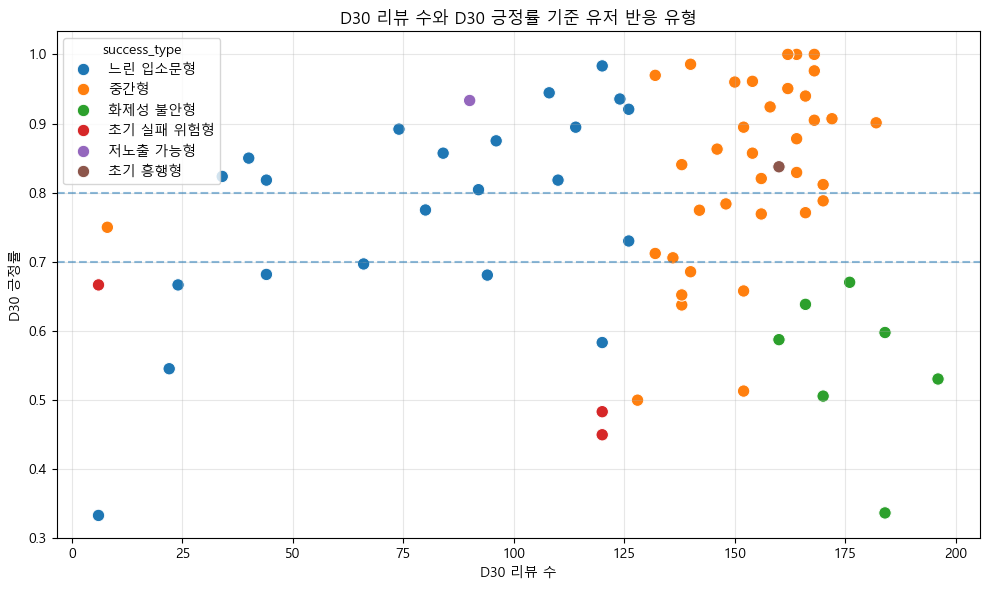

In [66]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=final_success_df,
    x="d30_reviews",
    y="d30_positive_ratio",
    hue="success_type",
    s=80
)

plt.axhline(0.80, linestyle="--", alpha=0.5)
plt.axhline(0.70, linestyle="--", alpha=0.5)

plt.title("D30 리뷰 수와 D30 긍정률 기준 유저 반응 유형")
plt.xlabel("D30 리뷰 수")
plt.ylabel("D30 긍정률")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

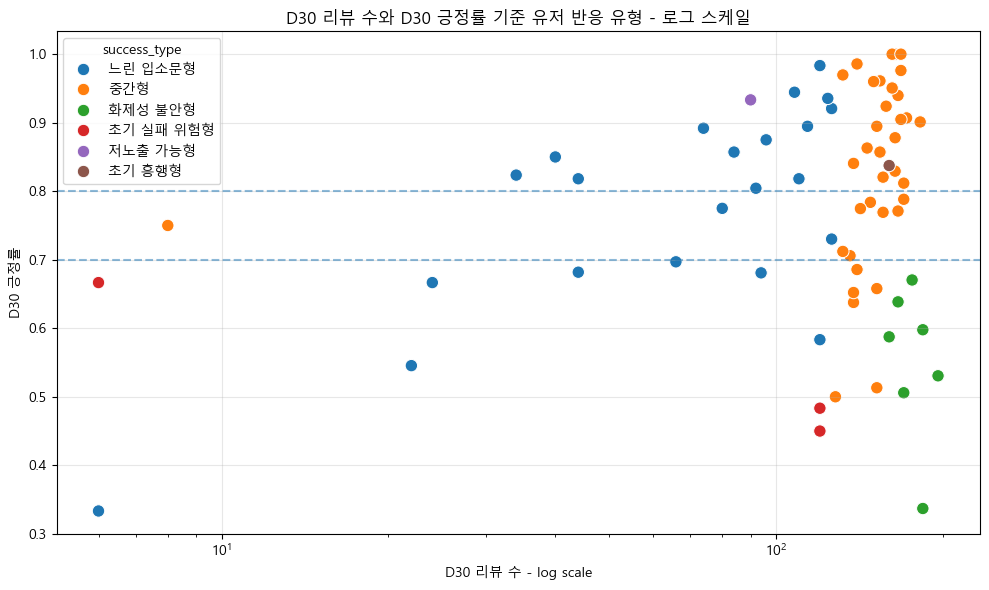

In [67]:
# 시각화 2: 로그 스케일
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=final_success_df,
    x="d30_reviews",
    y="d30_positive_ratio",
    hue="success_type",
    s=80
)

plt.xscale("log")

plt.axhline(0.80, linestyle="--", alpha=0.5)
plt.axhline(0.70, linestyle="--", alpha=0.5)

plt.title("D30 리뷰 수와 D30 긍정률 기준 유저 반응 유형 - 로그 스케일")
plt.xlabel("D30 리뷰 수 - log scale")
plt.ylabel("D30 긍정률")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 시각화 3: 반응 유지력 확인

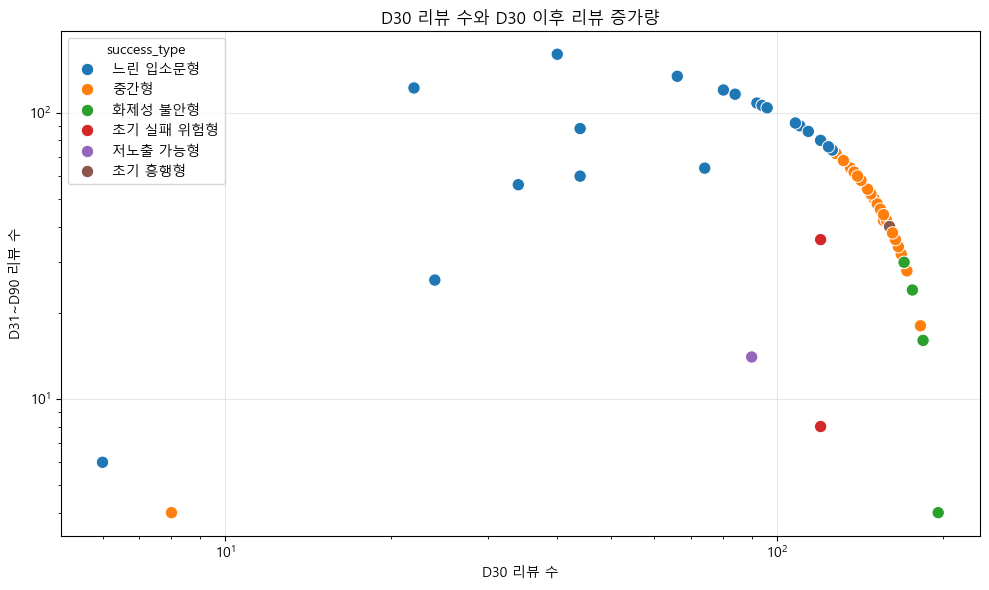

In [68]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=final_success_df,
    x="d30_reviews",
    y="post_d30_reviews",
    hue="success_type",
    s=80
)

plt.xscale("log")
plt.yscale("log")

plt.title("D30 리뷰 수와 D30 이후 리뷰 증가량")
plt.xlabel("D30 리뷰 수")
plt.ylabel("D31~D90 리뷰 수")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 최종 보고서 초안

## 분석 목적

본 분석은 Steam 인디게임의 흥행을 직접 매출이나 DAU로 측정하기 어려운 상황에서, 공개적으로 수집 가능한 리뷰 데이터를 활용해 **유저 반응 성과**를 정의하고 검증하는 것을 목적으로 한다.

기존의 단일 흥행지표 방식은 한계가 있다.  
리뷰 수가 많아도 부정 반응이 많으면 좋은 흥행이라고 보기 어렵고, 반대로 긍정률이 높아도 리뷰 수가 너무 적으면 평가를 신뢰하기 어렵다.  
또한 출시 초반에만 반응이 집중된 게임과 시간이 지난 뒤에도 반응이 유지되는 게임은 구분할 필요가 있다.

따라서 본 분석에서는 흥행을 단일 점수가 아니라 다음 3가지 축으로 나누어 정의했다.

1. **반응의 규모**
2. **반응의 품질**
3. **반응의 유지력**

## 지표 정의

### 반응의 규모

반응의 규모는 게임이 얼마나 많은 유저 반응을 만들어냈는지를 의미한다.  
본 분석에서는 D7, D30, D90 리뷰 수와 D30 리뷰 속도를 사용했다.

특히 D30 리뷰 수는 출시 초기 반응을 확인하기 위한 핵심 지표로 사용했다.  
이번 분석에서는 대표장르를 강제로 설정하지 않고, 전체 분석 표본의 D30 리뷰 수 분위수를 기준으로 반응 규모를 높음, 보통, 낮음으로 구분했다.

### 반응의 품질

반응의 품질은 유저 반응이 좋은 평가였는지를 의미한다.  
본 분석에서는 D30 긍정률을 핵심 지표로 사용했다.

다만 리뷰 수가 적은 게임은 긍정률이 과대평가될 수 있으므로, Wilson Score를 함께 사용해 긍정률의 신뢰도를 보정했다.  
따라서 Wilson Score는 긍정률을 대체하는 지표가 아니라, 긍정률의 안정성을 확인하는 보조 지표로 해석했다.

### 반응의 유지력

반응의 유지력은 출시 초반 이후에도 유저 관심이 이어지는지를 의미한다.  
본 분석에서는 D31~D90 리뷰 수와 D30 대비 이후 리뷰 증가 비율을 사용했다.

이를 통해 초반 반응은 크지만 이후 증가가 약한 게임과, 초반 반응은 크지 않았지만 이후 리뷰가 꾸준히 증가하는 게임을 구분할 수 있다.

## 분석 결과 해석

이번 분석은 유저 반응 성과를 다음과 같은 유형으로 구분했다.

| 유형 | 해석 |
|---|---|
| 초기 흥행형 | 출시 초기 반응 규모와 평가가 모두 좋은 유형 |
| 화제성 불안형 | 관심은 받았지만 긍정 평가가 낮아 위험한 유형 |
| 느린 입소문형 | 초반보다 이후 리뷰 증가가 강한 유형 |
| 저노출 가능형 | 평가 품질은 좋지만 초기 반응 규모가 낮은 유형 |
| 초기 실패 위험형 | 반응 규모와 평가 품질이 모두 낮은 유형 |
| 중간형 | 한 가지 유형으로 명확히 분류하기 어려운 유형 |

이 유형 분류는 게임의 성공과 실패를 단정하기 위한 것이 아니라, **개발사 입장에서 어떤 대응이 필요한지 판단하기 위한 진단 틀**로 해석해야 한다.

예를 들어 화제성 불안형은 초기 관심은 있었지만 부정 반응이 크기 때문에 부정 리뷰 원인 분석과 빠른 패치 대응이 중요하다.  
저노출 가능형은 평가가 좋음에도 리뷰 수가 낮기 때문에 마케팅, 노출, 타겟 유저 도달 전략을 점검할 필요가 있다.  
느린 입소문형은 출시 초반보다 이후 반응이 이어지는 유형이므로 장기 운영, 커뮤니티 관리, 후속 업데이트 전략과 연결할 수 있다.

## 결론

본 분석 결과, Steam 인디게임의 흥행은 단순 리뷰 수나 단순 긍정률 하나만으로 판단하기 어렵다.

리뷰 수는 반응의 규모를 보여주지만, 그 반응이 좋은지까지 설명하지는 못한다.  
긍정률은 반응의 품질을 보여주지만, 리뷰 수가 적으면 과대평가될 수 있다.  
또한 출시 초반 반응과 이후 반응은 서로 다른 의미를 가지므로, D30 이후 리뷰 증가량을 통해 반응 유지력을 별도로 확인해야 한다.

따라서 본 프로젝트에서는 흥행지표를 **반응의 규모, 반응의 품질, 반응의 유지력** 세 축으로 구성하는 것이 적절하다.  
이 3축 구조는 인디게임 개발사가 출시 초기 반응을 해석하고, 이후 패치 및 운영 전략을 판단하는 데 활용할 수 있는 분석 기준이 될 수 있다.